Установка

In [7]:
!pip install -q kaggle scikit-learn

import os
from google.colab import userdata

os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')
os.environ['KAGGLE_USERNAME']      = userdata.get('KAGGLE_USERNAME')

!kaggle datasets download -d raman77768/movie-classifier
!unzip -q -o movie-classifier.zip -d data/


Dataset URL: https://www.kaggle.com/datasets/raman77768/movie-classifier
License(s): CC0-1.0
movie-classifier.zip: Skipping, found more recently modified local copy (use --force to force download)


Импорты

In [8]:
import os, random, numpy as np, pandas as pd, torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
from PIL import Image
from sklearn.metrics import f1_score, average_precision_score
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


Датасет

ПРЕДАНАЛИЗ ДАТАСЕТА
Всего фильмов:       7254
Всего жанров в CSV:  25
Среднее число жанров на фильм: 2.33
Максимум жанров у одного фильма: 3


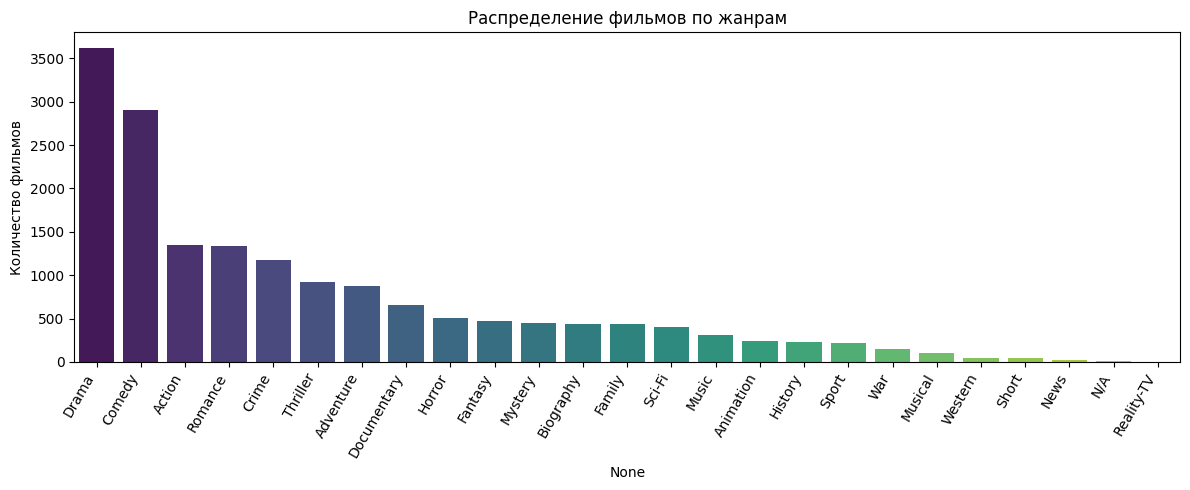


Топ-15 самых популярных жанров:
Drama          3619
Comedy         2900
Action         1343
Romance        1334
Crime          1176
Thriller        918
Adventure       870
Documentary     652
Horror          503
Fantasy         467
Mystery         454
Biography       441
Family          434
Sci-Fi          399
Music           305

Хвост — самые редкие 10:
Animation     244
History       224
Sport         221
War           144
Musical        97
Western        50
Short          46
News           21
N/A            10
Reality-TV      2


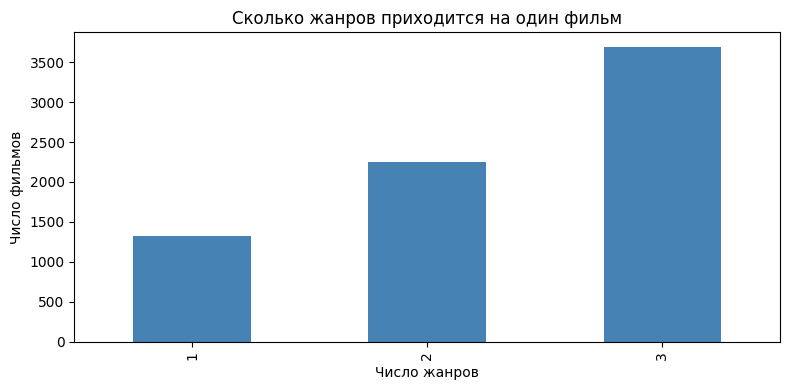


ФИЛЬТРАЦИЯ: оставляем топ-5 жанров
Оставлены:   ['Drama', 'Comedy', 'Action', 'Romance', 'Crime']
Исключены:   ['Adventure', 'Animation', 'Biography', 'Documentary', 'Family', 'Fantasy', 'History', 'Horror', 'Music', 'Musical', 'Mystery', 'N/A', 'News', 'Reality-TV', 'Sci-Fi', 'Short', 'Sport', 'Thriller', 'War', 'Western']

Фильмов до фильтрации:    7254
Фильмов после фильтрации: 6206  (исключено 1048)
Среднее жанров на фильм после фильтрации: 1.67


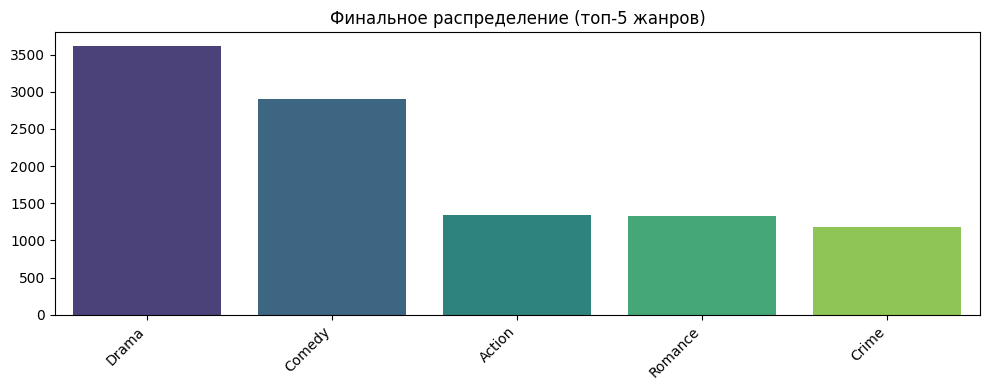

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

DATA_DIR = "data/Multi_Label_dataset"
df = pd.read_csv(f"{DATA_DIR}/train.csv")

ALL_GENRES = [c for c in df.columns if c not in ("Id", "Genre")]

print("="*60)
print("ПРЕДАНАЛИЗ ДАТАСЕТА")
print("="*60)
print(f"Всего фильмов:       {len(df)}")
print(f"Всего жанров в CSV:  {len(ALL_GENRES)}")
print(f"Среднее число жанров на фильм: {df[ALL_GENRES].sum(axis=1).mean():.2f}")
print(f"Максимум жанров у одного фильма: {df[ALL_GENRES].sum(axis=1).max()}")

# === 1. Распределение жанров (сколько фильмов каждого) ===
genre_counts = df[ALL_GENRES].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
sns.barplot(x=genre_counts.index, y=genre_counts.values,
            palette="viridis", hue=genre_counts.index, legend=False)
plt.xticks(rotation=60, ha="right")
plt.title("Распределение фильмов по жанрам")
plt.ylabel("Количество фильмов")
plt.tight_layout(); plt.show()

print("\nТоп-15 самых популярных жанров:")
print(genre_counts.head(15).to_string())
print("\nХвост — самые редкие 10:")
print(genre_counts.tail(10).to_string())

# === 2. Распределение по числу жанров на фильм ===
n_genres_per_film = df[ALL_GENRES].sum(axis=1)
plt.figure(figsize=(8, 4))
n_genres_per_film.value_counts().sort_index().plot(kind="bar", color="steelblue")
plt.title("Сколько жанров приходится на один фильм")
plt.xlabel("Число жанров"); plt.ylabel("Число фильмов")
plt.tight_layout(); plt.show()

# === 3. Фильтрация — оставляем топ-K жанров ===
TOP_K = 5   # ← можешь поменять (10-12 оптимально)

GENRE_COLS = genre_counts.head(TOP_K).index.tolist()
print("\n" + "="*60)
print(f"ФИЛЬТРАЦИЯ: оставляем топ-{TOP_K} жанров")
print("="*60)
print("Оставлены:  ", GENRE_COLS)
print("Исключены:  ", [g for g in ALL_GENRES if g not in GENRE_COLS])

# Оставляем в df только Id + выбранные жанры
df = df[["Id", "Genre"] + GENRE_COLS].copy()

# Выкидываем фильмы у которых после фильтрации не осталось ни одной метки
before = len(df)
df = df[df[GENRE_COLS].sum(axis=1) > 0].reset_index(drop=True)
after = len(df)

print(f"\nФильмов до фильтрации:    {before}")
print(f"Фильмов после фильтрации: {after}  (исключено {before - after})")
print(f"Среднее жанров на фильм после фильтрации: {df[GENRE_COLS].sum(axis=1).mean():.2f}")

# === 4. Финальное распределение ===
plt.figure(figsize=(10, 4))
sns.barplot(x=GENRE_COLS, y=df[GENRE_COLS].sum().values,
            palette="viridis", hue=GENRE_COLS, legend=False)
plt.xticks(rotation=45, ha="right")
plt.title(f"Финальное распределение (топ-{TOP_K} жанров)")
plt.tight_layout(); plt.show()


Классы

In [10]:
class PosterDataset(Dataset):
    def __init__(self, df, img_dir, genre_cols, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.genre_cols = genre_cols
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(f"{self.img_dir}/{row['Id']}.jpg").convert("RGB")
        if self.transform:
            img = self.transform(img)
        labels = torch.tensor(row[self.genre_cols].values.astype("float32"))
        return img, labels

IMG_SIZE = 384
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandAugment(num_ops=2, magnitude=9),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.25),
])
val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

full_train_df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)
split = int(len(full_train_df) * 0.85)
train_df, val_df = full_train_df[:split], full_train_df[split:]

IMG_DIR = f"{DATA_DIR}/Images"
train_ds = PosterDataset(train_df, IMG_DIR, GENRE_COLS, train_tf)
val_ds   = PosterDataset(val_df,   IMG_DIR, GENRE_COLS, val_tf)


train_loader = DataLoader(train_ds, batch_size=16, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)


ConvNeXt-Tiny

In [11]:
NUM_CLASSES = len(GENRE_COLS)

model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1)
in_features = model.classifier[2].in_features
model.classifier[2] = nn.Linear(in_features, NUM_CLASSES)
model = model.to(device)

# pos_weight = N_neg / N_pos на класс — компенсирует дисбаланс,
# редкие жанры получают больший вклад в loss.
pos_counts = torch.tensor(train_df[GENRE_COLS].sum().values, dtype=torch.float32)
neg_counts = len(train_df) - pos_counts
pos_weight = (neg_counts / pos_counts.clamp(min=1)).clamp(max=20.0).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15)


Обучение

In [12]:
import os, json

CHECKPOINT     = "best_convnext_posters.pt"
HISTORY_PATH   = "training_history.json"
THRESHOLDS_PATH = "thresholds.json"

def collect_probs(model, loader):
    model.eval()
    all_logits, all_labels = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            all_logits.append(model(x).cpu()); all_labels.append(y)
    logits = torch.cat(all_logits); labels = torch.cat(all_labels)
    return torch.sigmoid(logits).numpy(), labels.numpy()

def tune_thresholds(probs, labels):
    """Подбирает порог под каждый класс по максимуму F1 на валидации."""
    thresholds = np.zeros(probs.shape[1], dtype=np.float32)
    grid = np.linspace(0.05, 0.95, 19)
    for k in range(probs.shape[1]):
        best_t, best_f1 = 0.5, -1.0
        for t in grid:
            f = f1_score(labels[:, k], (probs[:, k] > t).astype(int), zero_division=0)
            if f > best_f1: best_t, best_f1 = float(t), f
        thresholds[k] = best_t
    return thresholds

def evaluate(model, loader, thresholds=None):
    probs, labels = collect_probs(model, loader)
    t = 0.5 if thresholds is None else thresholds[None, :]
    preds = (probs > t).astype(int)
    return {
        "f1_micro": f1_score(labels, preds, average="micro", zero_division=0),
        "f1_macro": f1_score(labels, preds, average="macro", zero_division=0),
        "mAP":      average_precision_score(labels, probs, average="macro"),
    }

history = None

if os.path.exists(CHECKPOINT):
    print(f"Найден чекпойнт '{CHECKPOINT}' — пропускаю обучение, загружаю веса.")
    model.load_state_dict(torch.load(CHECKPOINT, map_location=device))
    model = model.to(device)
else:
    print("Чекпойнт не найден — запускаю обучение.")
    EPOCHS   = 30
    PATIENCE = 4
    history = {"train_loss": [], "f1_micro": [], "f1_macro": [], "mAP": []}
    best_f1 = -1.0
    best_epoch = 0
    epochs_no_improve = 0

    for epoch in range(1, EPOCHS + 1):
        model.train()
        running = 0.0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward(); optimizer.step()
            running += loss.item() * x.size(0)
        scheduler.step()

        train_loss = running / len(train_ds)
        metrics = evaluate(model, val_loader)
        for k, v in metrics.items(): history[k].append(float(v))
        history["train_loss"].append(float(train_loss))

        with open(HISTORY_PATH, "w") as f:
            json.dump(history, f, indent=2)

        improved = metrics["f1_micro"] > best_f1
        marker = ""
        if improved:
            best_f1 = metrics["f1_micro"]
            best_epoch = epoch
            epochs_no_improve = 0
            torch.save(model.state_dict(), CHECKPOINT)
            marker = "  <- new best, saved"
        else:
            epochs_no_improve += 1

        print(f"Ep {epoch:2d} | loss {train_loss:.4f} | F1-micro {metrics['f1_micro']:.3f} "
              f"| F1-macro {metrics['f1_macro']:.3f} | mAP {metrics['mAP']:.3f}{marker}")

        if epochs_no_improve >= PATIENCE:
            print(f"\nEarly stopping: {PATIENCE} эпох без улучшения.")
            break

    print(f"\nЛучший F1-micro (порог 0.5) = {best_f1:.3f} на эпохе {best_epoch}.")
    model.load_state_dict(torch.load(CHECKPOINT, map_location=device))
    model = model.to(device)

val_probs, val_labels = collect_probs(model, val_loader)
thresholds = tune_thresholds(val_probs, val_labels)
with open(THRESHOLDS_PATH, "w") as f:
    json.dump({g: float(t) for g, t in zip(GENRE_COLS, thresholds)}, f, indent=2)

base = evaluate(model, val_loader)
tuned = evaluate(model, val_loader, thresholds=thresholds)
print(f"\nС порогом 0.5:       F1-micro {base['f1_micro']:.3f} | F1-macro {base['f1_macro']:.3f} | mAP {base['mAP']:.3f}")
print(f"С тюнингом порогов:  F1-micro {tuned['f1_micro']:.3f} | F1-macro {tuned['f1_macro']:.3f} | mAP {tuned['mAP']:.3f}")
print(f"\nПороги сохранены в {THRESHOLDS_PATH}")

if history is None and os.path.exists(HISTORY_PATH):
    with open(HISTORY_PATH) as f:
        history = json.load(f)

print("Модель готова к использованию.")


Чекпойнт не найден — запускаю обучение.
Ep  1 | loss 0.8181 | F1-micro 0.604 | F1-macro 0.573 | mAP 0.602  <- new best, saved
Ep  2 | loss 0.7502 | F1-micro 0.621 | F1-macro 0.576 | mAP 0.611  <- new best, saved
Ep  3 | loss 0.7033 | F1-micro 0.624 | F1-macro 0.592 | mAP 0.615  <- new best, saved
Ep  4 | loss 0.6459 | F1-micro 0.633 | F1-macro 0.582 | mAP 0.605  <- new best, saved
Ep  5 | loss 0.5951 | F1-micro 0.646 | F1-macro 0.602 | mAP 0.618  <- new best, saved
Ep  6 | loss 0.5168 | F1-micro 0.628 | F1-macro 0.586 | mAP 0.616
Ep  7 | loss 0.4322 | F1-micro 0.639 | F1-macro 0.592 | mAP 0.612
Ep  8 | loss 0.3360 | F1-micro 0.644 | F1-macro 0.579 | mAP 0.609
Ep  9 | loss 0.2581 | F1-micro 0.639 | F1-macro 0.568 | mAP 0.607

Early stopping: 4 эпох без улучшения.

Лучший F1-micro (порог 0.5) = 0.646 на эпохе 5.

С порогом 0.5:       F1-micro 0.646 | F1-macro 0.602 | mAP 0.618
С тюнингом порогов:  F1-micro 0.648 | F1-macro 0.612 | mAP 0.618

Пороги сохранены в thresholds.json
Модель гото

Графики

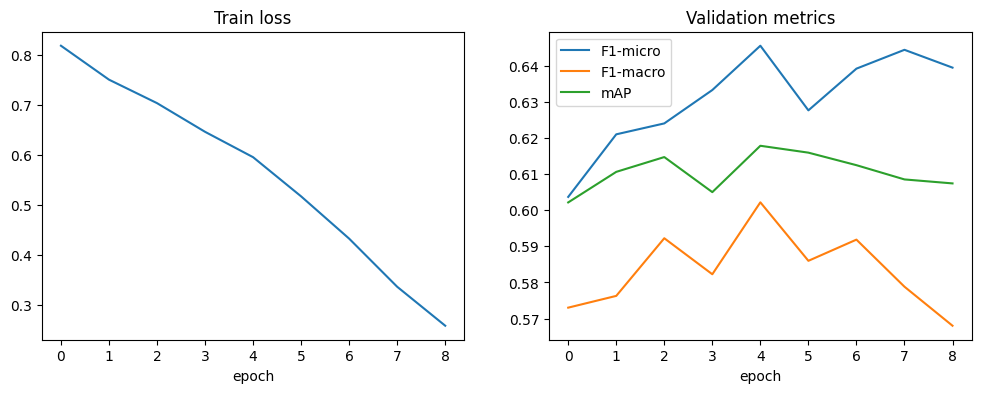

In [13]:
if history is None:
    print("Обучение в этой сессии не запускалось (модель загружена из чекпойнта) — графиков нет.")
else:
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(history["train_loss"]); ax[0].set_title("Train loss"); ax[0].set_xlabel("epoch")
    ax[1].plot(history["f1_micro"], label="F1-micro")
    ax[1].plot(history["f1_macro"], label="F1-macro")
    ax[1].plot(history["mAP"],      label="mAP")
    ax[1].set_title("Validation metrics"); ax[1].legend(); ax[1].set_xlabel("epoch")
    plt.show()


Экспорт в ONNX

In [14]:
!pip install -q onnxscript onnx

import torch, onnx, glob
from google.colab import files

ONNX_PATH = "model.onnx"
model.eval()
dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE, device=device)
torch.onnx.export(
    model, dummy, ONNX_PATH,
    input_names=["input"], output_names=["logits"],
    opset_version=17,
    dynamic_axes={"input": {0: "batch"}, "logits": {0: "batch"}},
    dynamo=False,
)

m = onnx.load(ONNX_PATH, load_external_data=True)
onnx.save(m, ONNX_PATH, save_as_external_data=False)
for extra in glob.glob("model.onnx.data*"):
    os.remove(extra)

print(f"Сохранено: {ONNX_PATH} ({os.path.getsize(ONNX_PATH)/1e6:.1f} МБ)")

for f in (ONNX_PATH, "best_convnext_posters.pt", "training_history.json", "thresholds.json"):
    if os.path.exists(f):
        files.download(f)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 60.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 17.6 MB/s eta 0:00:00


/tmp/ipykernel_2260/2097562908.py:9: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


Сохранено: model.onnx (111.4 МБ)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
from google.colab import drive
drive.mount('/content/drive')

!mkdir -p /content/drive/MyDrive/poster_classifier
!cp -v best_convnext_posters.pt    /content/drive/MyDrive/poster_classifier/ 2>/dev/null
!cp -v training_history.json       /content/drive/MyDrive/poster_classifier/ 2>/dev/null
!cp -v model.onnx      /content/drive/MyDrive/poster_classifier/ 2>/dev/null

!ls -lh /content/drive/MyDrive/poster_classifier/


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
'best_convnext_posters.pt' -> '/content/drive/MyDrive/poster_classifier/best_convnext_posters.pt'
'training_history.json' -> '/content/drive/MyDrive/poster_classifier/training_history.json'
'model.onnx' -> '/content/drive/MyDrive/poster_classifier/model.onnx'
total 213M
-rw------- 1 root root 107M Jun  7 18:06 best_convnext_posters.pt
-rw------- 1 root root 107M Jun  7 18:06 model.onnx
-rw------- 1 root root  933 Jun  7 18:06 training_history.json
